In [264]:
from PIL import Image
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os

print("Done.")

Done.


In [280]:
option_print = True 

num_classes = 7 # number of classes in clustering
params = ["Ua","Ui","Ga","Gi","Da","Di","Ba"] # feature parameters to use
colors = ["red","green","blue","purple","orange","black","pink"] # colors for each class
num_PCA_components = 2 # number of PCA components to use

pd.set_option('display.max_columns', None)

In [281]:
file_in = "data/unclassified_features_39517_KM_classes_7_s42"

with open(file_in + ".pkl", 'rb') as f:
  feats_df_large = pickle.load(f) # deserialize using load()

print(feats_df_large.shape)

# these unclassified images are from the proper parameter range
file_in_narrow = "data/unclassified_features_33770"

with open(file_in_narrow + ".pkl", 'rb') as f:
  df_narrow = pickle.load(f)

print(df_narrow.shape)

(39517, 114)
(33770, 111)


In [282]:
# Create output directories
output_dir = "data/output_images/"
os.makedirs(output_dir, exist_ok=True)

output_sub_dir = output_dir + file_in[5:] + "/"
os.makedirs(output_sub_dir, exist_ok=True)

specific_file_dir = output_sub_dir + "Visualization_Features_Parameters/"
os.makedirs(specific_file_dir, exist_ok=True)

In [283]:
feats_df = feats_df_large[feats_df_large["path"].isin(df_narrow["path"].unique())]
feats_df.reset_index(inplace = True, drop = True)

print(feats_df.shape)
feats_df.head()

(33770, 114)


,Ua,Ui,Ga,Gi,Ba,Da,Di,pattern,noise,path,seed,dir,feat_bool,num_spots,Mean,Median,Area_mean,Area_std,X_mean,X_std,Y_mean,Y_std,Perim._mean,Perim._std,BX_mean,BX_std,BY_mean,BY_std,Width_mean,Width_std,Height_mean,Height_std,Major_mean,Major_std,Minor_mean,Minor_std,Angle_mean,Angle_std,Circ._mean,Circ._std,Feret_mean,Feret_std,IntDen_mean,IntDen_std,%Area_mean,%Area_std,RawIntDen_mean,RawIntDen_std,FeretX_mean,FeretX_std,FeretY_mean,FeretY_std,FeretAngle_mean,FeretAngle_std,MinFeret_mean,MinFeret_std,AR_mean,AR_std,Round_mean,Round_std,Solidity_mean,Solidity_std,num_spots_inverted,Mean_inverted,Median_inverted,Area_inverted_mean,Area_inverted_std,X_inverted_mean,X_inverted_std,Y_inverted_mean,Y_inverted_std,Perim._inverted_mean,Perim._inverted_std,BX_inverted_mean,BX_inverted_std,BY_inverted_mean,BY_inverted_std,Width_inverted_mean,Width_inverted_std,Height_inverted_mean,Height_inverted_std,Major_inverted_mean,Major_inverted_std,Minor_inverted_mean,Minor_inverted_std,Angle_inverted_mean,Angle_inverted_std,Circ._inverted_mean,Circ._inverted_std,Feret_inverted_mean,Feret_inverted_std,IntDen_inverted_mean,IntDen_inverted_std,%Area_inverted_mean,%Area_inverted_std,RawIntDen_inverted_mean,RawIntDen_inverted_std,FeretX_inverted_mean,FeretX_inverted_std,FeretY_inverted_mean,FeretY_inverted_std,FeretAngle_inverted_mean,FeretAngle_inverted_std,MinFeret_inverted_mean,MinFeret_inverted_std,AR_inverted_mean,AR_inverted_std,Round_inverted_mean,Round_inverted_std,Solidity_inverted_mean,Solidity_inverted_std,pc1,pc2,cluster
0,0.025122,0.063822,0.071957,0.106327,-0.113131,0.009186,0.611871,1,2,1.png,1,/content/Images3/,1,70,5.489,0,12.300000,2.548669,99.395943,58.506181,97.530229,58.913237,12.282143,1.400962,97.371429,58.453442,95.528571,58.843551,4.071429,0.723512,4.057143,0.753766,4.245571,0.439294,3.664200,0.511781,55.108900,57.413924,0.958686,0.069883,4.926700,0.412294,3136.500000,649.910626,100.0,0.0,3136.500000,649.910626,97.942857,58.572760,96.014286,58.843981,120.129000,30.775307,3.653171,0.564778,1.177686,0.183575,0.866686,0.115368,0.879486,0.067138,1,249.511,255,39139.0,0.0,99.998,0.0,100.022,0.0,811.882,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,223.351,0.0,223.117,0.0,38.796,0.0,0.746,0.0,282.843,0.0,9980445.0,0.0,100.0,0.0,9980445.0,0.0,0.0,0.0,200.0,0.0,45.0,0.0,200.0,0.0,1.001,0.0,0.999,0.0,0.979,0.0,3.426621,5.976980,0
1,0.034475,0.059956,0.080798,0.10037,-0.132577,0.008852,0.854084,1,2,3.png,3,/content/Images3/,1,63,4.921,0,12.253968,2.569468,101.800571,59.297600,99.451270,58.953924,11.663270,1.365051,99.968254,59.323693,97.619048,58.964458,3.666667,0.534522,3.666667,0.534522,4.237317,0.401713,3.661714,0.572434,56.049556,60.605082,0.999619,0.003000,4.908365,0.491745,3124.761905,655.214389,100.0,0.0,3124.761905,655.214389,100.158730,59.330446,98.079365,59.017431,120.191190,32.406426,3.476190,0.613529,1.185032,0.226780,0.867667,0.127976,0.954905,0.046408,1,250.078,255,39228.0,0.0,99.992,0.0,100.015,0.0,809.255,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,223.524,0.0,223.451,0.0,72.380,0.0,0.753,0.0,282.843,0.0,10003140.0,0.0,100.0,0.0,10003140.0,0.0,0.0,0.0,0.0,0.0,135.0,0.0,200.0,0.0,1.000,0.0,1.000,0.0,0.981,0.0,2.593979,6.079593,6
2,0.028367,0.057912,0.073998,0.080784,-0.133789,0.008512,0.534244,1,2,7.png,7,/content/Images3/,1,77,4.692,0,9.558442,1.427863,100.557675,58.022388,98.103338,59.633687,10.379961,1.091819,98.870130,58.006796,96.519481,59.576560,3.402597,0.564300,3.194805,0.559196,3.806623,0.403173,3.196818,0.352550,29.220831,46.845042,0.992974,0.032896,4.416805,0.320359,2437.402597,364.105032,100.0,0.0,2437.402597,364.105032,98.961039,57.996292,96.753247,59.526521,133.450130,23.616781,2.961039,0.375951,1.209857,0.220792,0.849429,0.129524,0.946805,0.050966,1,250.308,255,39264.0,0.0,99.987,0.0,100.001,0.0,808.326,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,223.626,0.0,223.554,0.0,5.766,0.0,0.755,0.0,282.843,0.0,10012320.0,0.0,100.0,0.0,10012320.0,0.0,0.0,0.0,200.0,0.0,45.0,0.0,200.0,0.0,1.000,0.0,1.000,0.0,0.982,0.0,2.872217,5.81

In [284]:
classes = np.arange(0,num_classes)# list of unique clusters

class_dfs = [] # list of dfs for each cluster

feats_df = feats_df.copy()
for i in ["Ua","Ui","Ga","Gi","Da","Di","Ba"]:
    feats_df[i] = feats_df[i].astype(float)

for i in classes:
    df = feats_df[feats_df["cluster"] == i]
    df.reset_index(inplace = True, drop = True)
    class_dfs.append(df)

    print(class_dfs[i].shape)

(2396, 114)
(10644, 114)
(942, 114)
(9399, 114)
(833, 114)
(982, 114)
(8574, 114)


In [285]:
feats_df[feats_df.columns[13:111]].columns

Index(['num_spots', 'Mean', 'Median', 'Area_mean', 'Area_std', 'X_mean',
       'X_std', 'Y_mean', 'Y_std', 'Perim._mean', 'Perim._std', 'BX_mean',
       'BX_std', 'BY_mean', 'BY_std', 'Width_mean', 'Width_std', 'Height_mean',
       'Height_std', 'Major_mean', 'Major_std', 'Minor_mean', 'Minor_std',
       'Angle_mean', 'Angle_std', 'Circ._mean', 'Circ._std', 'Feret_mean',
       'Feret_std', 'IntDen_mean', 'IntDen_std', '%Area_mean', '%Area_std',
       'RawIntDen_mean', 'RawIntDen_std', 'FeretX_mean', 'FeretX_std',
       'FeretY_mean', 'FeretY_std', 'FeretAngle_mean', 'FeretAngle_std',
       'MinFeret_mean', 'MinFeret_std', 'AR_mean', 'AR_std', 'Round_mean',
       'Round_std', 'Solidity_mean', 'Solidity_std', 'num_spots_inverted',
       'Mean_inverted', 'Median_inverted', 'Area_inverted_mean',
       'Area_inverted_std', 'X_inverted_mean', 'X_inverted_std',
       'Y_inverted_mean', 'Y_inverted_std', 'Perim._inverted_mean',
       'Perim._inverted_std', 'BX_inverted_mean', 'BX_

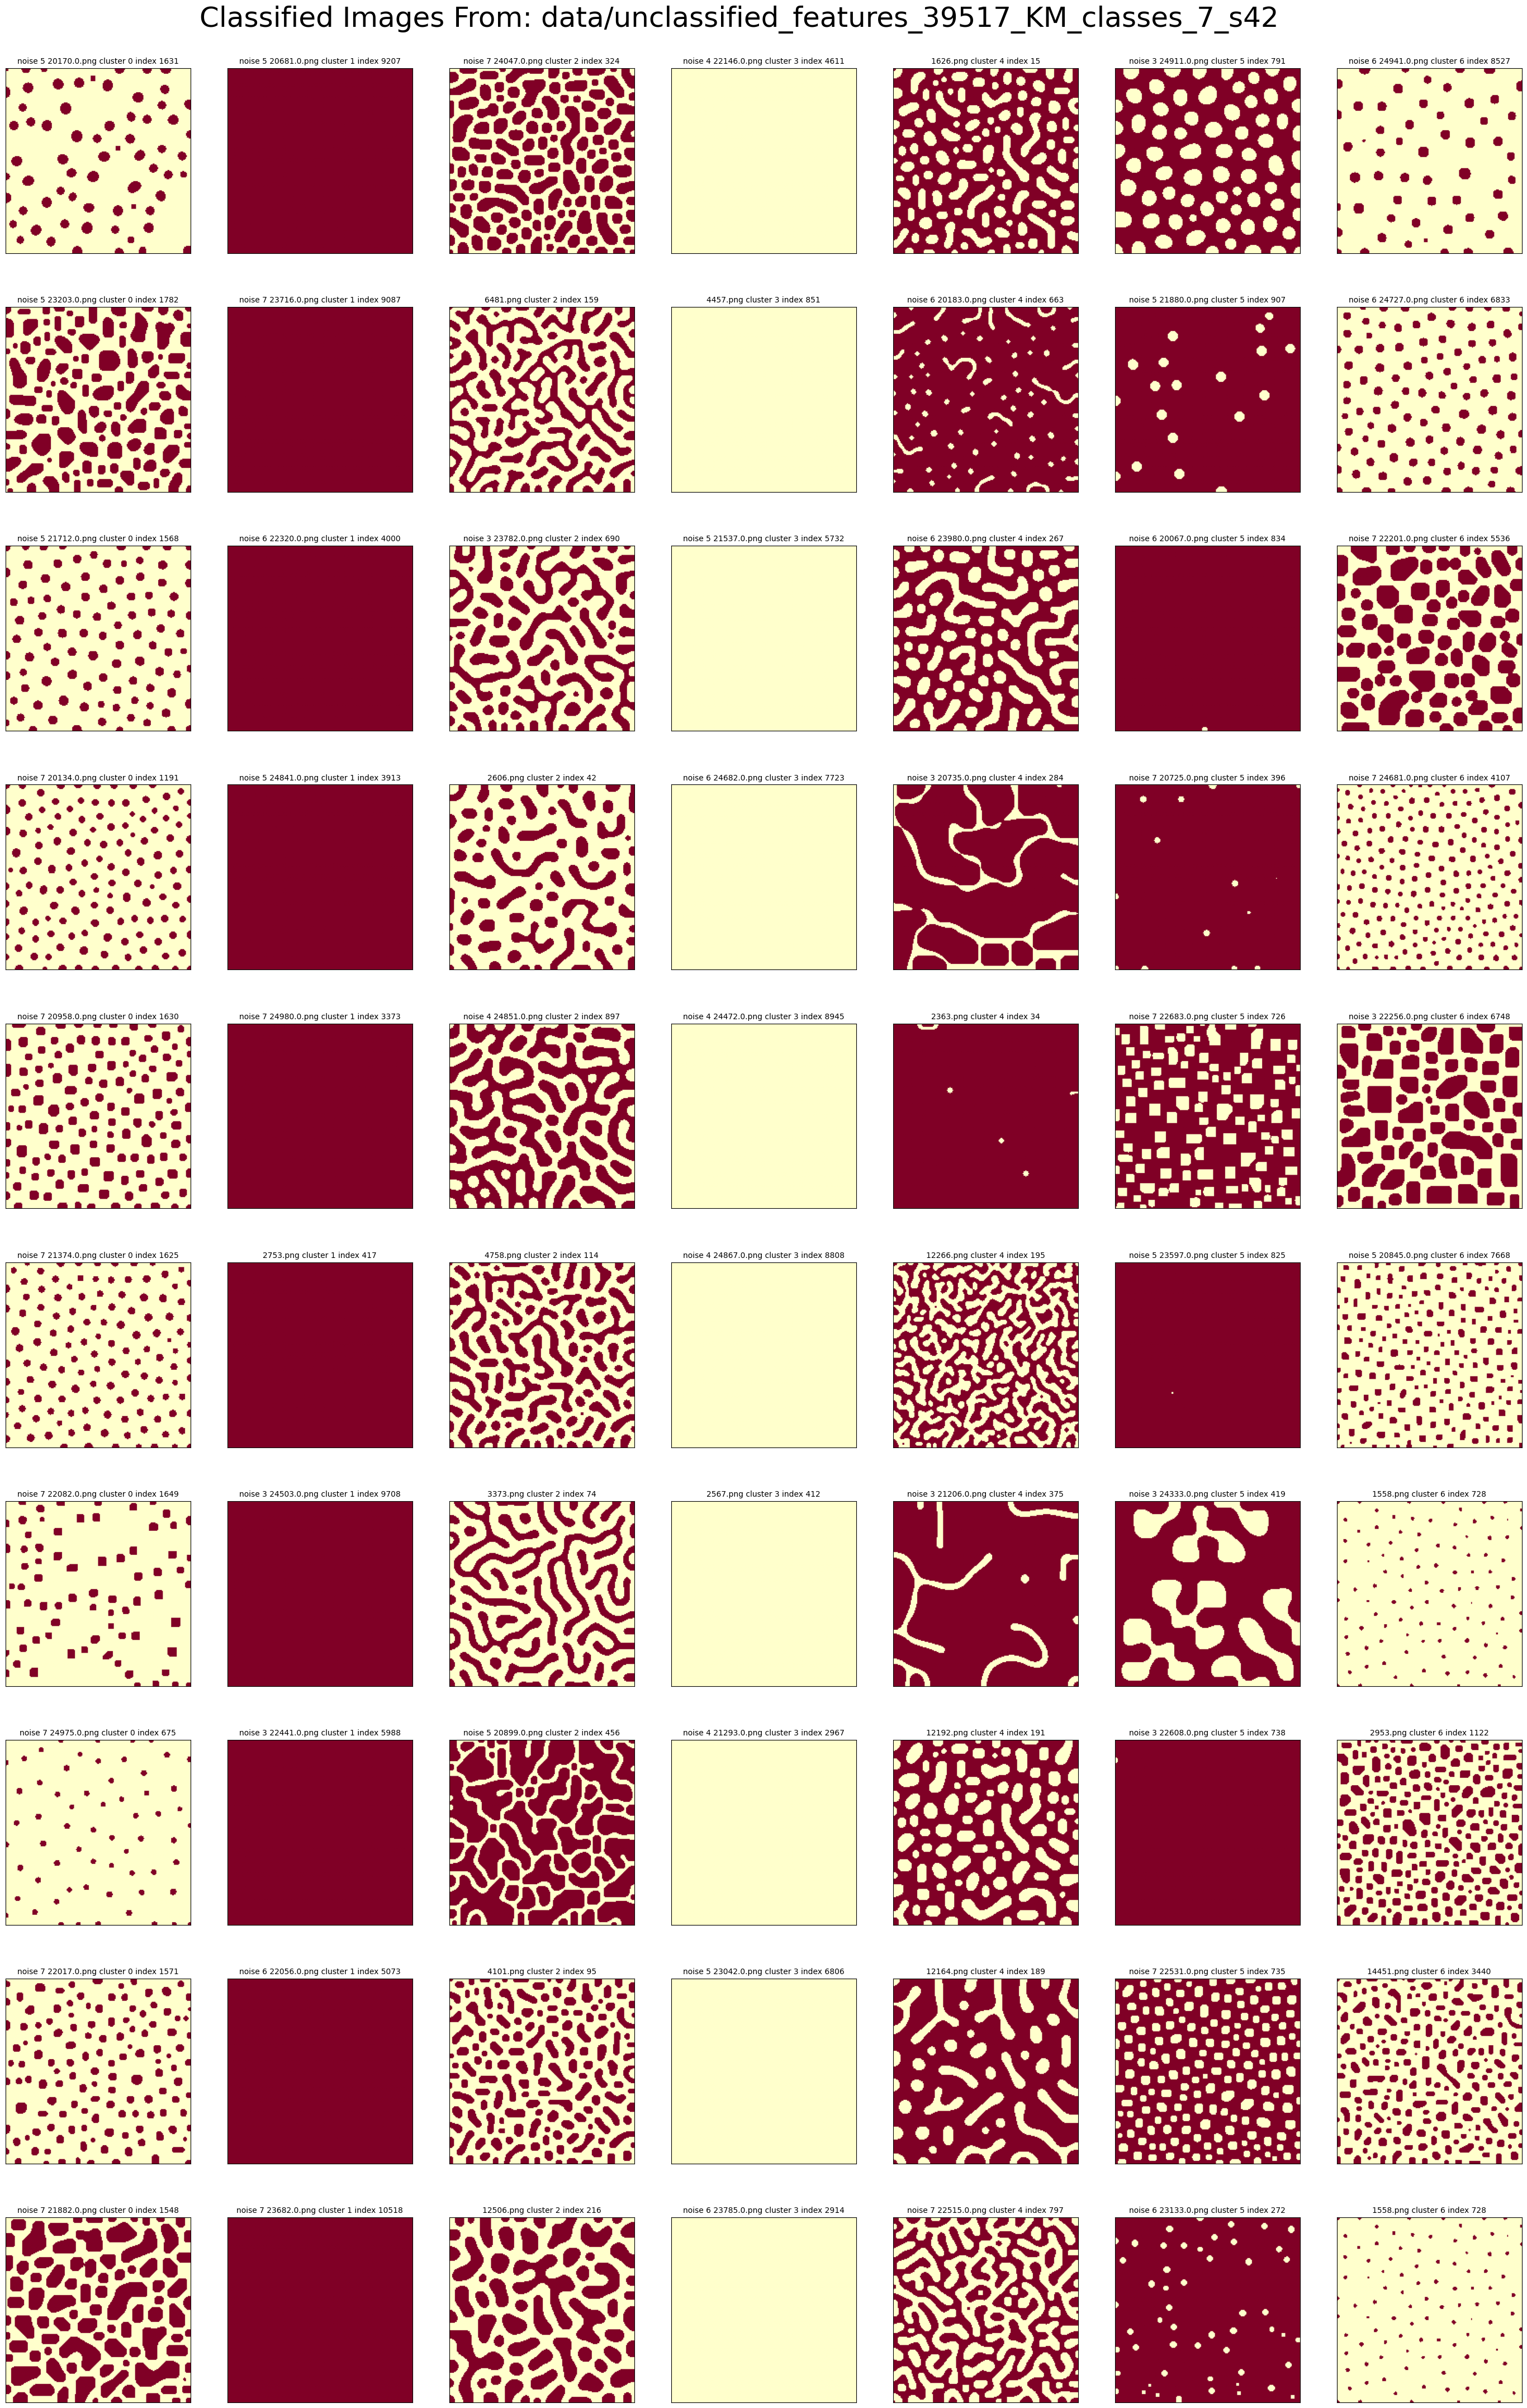

In [271]:
num_imgs = 10

fig, ax = plt.subplots(num_imgs, len(class_dfs))
fig.suptitle('Classified Images From: ' + file_in, fontsize=36, y=0.97)
plt.subplots_adjust(top=0.95)

for i in range(num_imgs):
  for j in range(len(class_dfs)):
    df = class_dfs[j]
    if df.shape[0] == 0:
      continue
    num = np.random.randint(low = 0, high= df.shape[0], size=1, dtype=int)[0]
    image_path = df["dir"][num] + df["path"][num]
    img = np.array(Image.open(image_path[1:]))
    ax[i][j].imshow(img, cmap = "YlOrRd", vmin = 0, vmax = 255)
    ax[i][j].set_title(df["path"][num] + " cluster " + str(j) + " index " + str(num), fontsize = 10)
    ax[i][j].get_xaxis().set_visible(False)
    ax[i][j].get_yaxis().set_visible(False)

fig.set_figwidth(5*len(class_dfs))
fig.set_figheight(5 * num_imgs)

# option_print = True
if option_print:
  plt.savefig(specific_file_dir + "ClassifiedImages_RandomImagesPerClass.png", dpi = 300)

plt.show()

In [286]:
# PCA on feat arrays

# scaling data
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

# feat_array_scaled contain only features (no image data)
feat_array_scaled = pd.DataFrame(sc.fit_transform(feats_df[feats_df.columns[13:111]]))
print(feat_array_scaled.shape)

# Applying PCA function on training and testing set of X component
from sklearn.decomposition import PCA

pca = PCA(n_components = num_PCA_components)
pca_data = pca.fit_transform(feat_array_scaled)

explained_variance = pca.explained_variance_ratio_
print(explained_variance)

for j in range(num_PCA_components):
    feats_df["pc"+str(j+1)] = pca_data[:,j]

class_dfs = [df.copy() for df in class_dfs]
for i in range(num_classes):
    class_subset = feats_df[feats_df["cluster"] == i]
    for j in range(num_PCA_components):
        class_dfs[i].loc[:,"pc" + str(j+1)] = class_subset["pc" + str(j+1)].values

# PCA components (loadings)
loadings = pd.DataFrame(pca.components_.T,
                        columns=[f'PC{i+1}' for i in range(len(pca.components_))],
                        index=feat_array_scaled.columns)

print("PCA Loadings:")
print(loadings)

# Find top features for each principal component
top_features = {}
for pc in loadings.columns:
    top_features[pc] = loadings[pc].abs().nlargest(3).index.tolist()  # Top 3 contributing features
print("\nTop Contributing Features per Principal Component:")
print(top_features)

for j in range(num_PCA_components):
    print("PC" + str(j+1)+ ":")
    for feat in top_features["PC"+str(j+1)]:
        print(f"----{feats_df.columns[feat + 13]}")

(33770, 98)
[0.40836246 0.25400039]
PCA Loadings:
         PC1       PC2
0   0.069040  0.144322
1  -0.017278 -0.115261
2  -0.018570 -0.135003
3  -0.114576 -0.135845
4   0.087308 -0.073634
..       ...       ...
93  0.092078 -0.086008
94 -0.122192  0.105278
95  0.124340 -0.112480
96 -0.100587 -0.072567
97  0.122978 -0.088004

[98 rows x 2 columns]

Top Contributing Features per Principal Component:
{'PC1': [26, 45, 52], 'PC2': [25, 9, 58]}
PC1:
----Circ._std
----Round_mean
----Area_inverted_mean
PC2:
----Circ._mean
----Perim._mean
----Perim._inverted_mean


In [287]:
# will show PCA columns added to feats_df
feats_df.head()

,Ua,Ui,Ga,Gi,Ba,Da,Di,pattern,noise,path,seed,dir,feat_bool,num_spots,Mean,Median,Area_mean,Area_std,X_mean,X_std,Y_mean,Y_std,Perim._mean,Perim._std,BX_mean,BX_std,BY_mean,BY_std,Width_mean,Width_std,Height_mean,Height_std,Major_mean,Major_std,Minor_mean,Minor_std,Angle_mean,Angle_std,Circ._mean,Circ._std,Feret_mean,Feret_std,IntDen_mean,IntDen_std,%Area_mean,%Area_std,RawIntDen_mean,RawIntDen_std,FeretX_mean,FeretX_std,FeretY_mean,FeretY_std,FeretAngle_mean,FeretAngle_std,MinFeret_mean,MinFeret_std,AR_mean,AR_std,Round_mean,Round_std,Solidity_mean,Solidity_std,num_spots_inverted,Mean_inverted,Median_inverted,Area_inverted_mean,Area_inverted_std,X_inverted_mean,X_inverted_std,Y_inverted_mean,Y_inverted_std,Perim._inverted_mean,Perim._inverted_std,BX_inverted_mean,BX_inverted_std,BY_inverted_mean,BY_inverted_std,Width_inverted_mean,Width_inverted_std,Height_inverted_mean,Height_inverted_std,Major_inverted_mean,Major_inverted_std,Minor_inverted_mean,Minor_inverted_std,Angle_inverted_mean,Angle_inverted_std,Circ._inverted_mean,Circ._inverted_std,Feret_inverted_mean,Feret_inverted_std,IntDen_inverted_mean,IntDen_inverted_std,%Area_inverted_mean,%Area_inverted_std,RawIntDen_inverted_mean,RawIntDen_inverted_std,FeretX_inverted_mean,FeretX_inverted_std,FeretY_inverted_mean,FeretY_inverted_std,FeretAngle_inverted_mean,FeretAngle_inverted_std,MinFeret_inverted_mean,MinFeret_inverted_std,AR_inverted_mean,AR_inverted_std,Round_inverted_mean,Round_inverted_std,Solidity_inverted_mean,Solidity_inverted_std,pc1,pc2,cluster
0,0.025122,0.063822,0.071957,0.106327,-0.113131,0.009186,0.611871,1,2,1.png,1,/content/Images3/,1,70,5.489,0,12.300000,2.548669,99.395943,58.506181,97.530229,58.913237,12.282143,1.400962,97.371429,58.453442,95.528571,58.843551,4.071429,0.723512,4.057143,0.753766,4.245571,0.439294,3.664200,0.511781,55.108900,57.413924,0.958686,0.069883,4.926700,0.412294,3136.500000,649.910626,100.0,0.0,3136.500000,649.910626,97.942857,58.572760,96.014286,58.843981,120.129000,30.775307,3.653171,0.564778,1.177686,0.183575,0.866686,0.115368,0.879486,0.067138,1,249.511,255,39139.0,0.0,99.998,0.0,100.022,0.0,811.882,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,223.351,0.0,223.117,0.0,38.796,0.0,0.746,0.0,282.843,0.0,9980445.0,0.0,100.0,0.0,9980445.0,0.0,0.0,0.0,200.0,0.0,45.0,0.0,200.0,0.0,1.001,0.0,0.999,0.0,0.979,0.0,3.196009,6.000280,0
1,0.034475,0.059956,0.080798,0.100370,-0.132577,0.008852,0.854084,1,2,3.png,3,/content/Images3/,1,63,4.921,0,12.253968,2.569468,101.800571,59.297600,99.451270,58.953924,11.663270,1.365051,99.968254,59.323693,97.619048,58.964458,3.666667,0.534522,3.666667,0.534522,4.237317,0.401713,3.661714,0.572434,56.049556,60.605082,0.999619,0.003000,4.908365,0.491745,3124.761905,655.214389,100.0,0.0,3124.761905,655.214389,100.158730,59.330446,98.079365,59.017431,120.191190,32.406426,3.476190,0.613529,1.185032,0.226780,0.867667,0.127976,0.954905,0.046408,1,250.078,255,39228.0,0.0,99.992,0.0,100.015,0.0,809.255,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,223.524,0.0,223.451,0.0,72.380,0.0,0.753,0.0,282.843,0.0,10003140.0,0.0,100.0,0.0,10003140.0,0.0,0.0,0.0,0.0,0.0,135.0,0.0,200.0,0.0,1.000,0.0,1.000,0.0,0.981,0.0,2.398773,6.018919,6
2,0.028367,0.057912,0.073998,0.080784,-0.133789,0.008512,0.534244,1,2,7.png,7,/content/Images3/,1,77,4.692,0,9.558442,1.427863,100.557675,58.022388,98.103338,59.633687,10.379961,1.091819,98.870130,58.006796,96.519481,59.576560,3.402597,0.564300,3.194805,0.559196,3.806623,0.403173,3.196818,0.352550,29.220831,46.845042,0.992974,0.032896,4.416805,0.320359,2437.402597,364.105032,100.0,0.0,2437.402597,364.105032,98.961039,57.996292,96.753247,59.526521,133.450130,23.616781,2.961039,0.375951,1.209857,0.220792,0.849429,0.129524,0.946805,0.050966,1,250.308,255,39264.0,0.0,99.987,0.0,100.001,0.0,808.326,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,223.626,0.0,223.554,0.0,5.766,0.0,0.755,0.0,282.843,0.0,10012320.0,0.0,100.0,0.0,10012320.0,0.0,0.0,0.0,200.0,0.0,45.0,0.0,200.0,0.0,1.000,0.0,1.000,0.0,0.982,0.0,2.655415,5.8

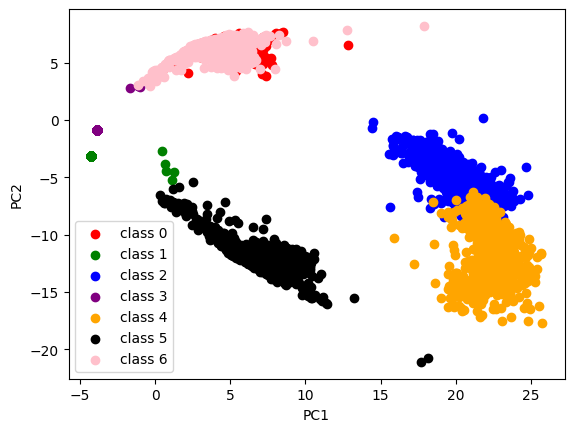

In [288]:
# plot the model predicted class in feature space
folder_name = "PCA_of_Features/"
os.makedirs(specific_file_dir + folder_name, exist_ok=True)

import plotly.graph_objects as go

feat_1 = "pc1"
feat_2 = "pc2"

alpha = [1,1,1,1,1,1,1]

if num_PCA_components == 2:
  fig, ax = plt.subplots()
  for j in classes:
    df = class_dfs[j]
    ax.scatter(df[feat_1], df[feat_2], c = colors[j], label = "class " + str(j), alpha = alpha[j])

  leg = ax.legend(loc="lower left")
  ax.set(xlabel = "PC1", ylabel = "PC2", title = "")

  # option_print = True
  if option_print:
    plt.savefig(specific_file_dir + folder_name + "PCA_of_Feats_2_Components.png", dpi = 300)
  plt.show()

if num_PCA_components == 3:
  feat_3 = "pc3"

  # 3D matplotlib plot
  fig = plt.figure(figsize=(8, 8))
  ax = plt.axes(projection='3d')

  for j in classes:
    df = class_dfs[j]
    ax.scatter3D(df[feat_1], df[feat_2], df[feat_3], c = colors[j], label = "class " + str(j), alpha = alpha[j])

  leg = ax.legend(loc="upper left")
  ax.set(xlabel = feat_1, ylabel = feat_2, zlabel = feat_3)
  ax.view_init(30,45)

  # enhanced 3D plot with plotly
  traces = []

  for i, df in enumerate(class_dfs):
    color = colors[i]
    cur_alpha = alpha[i]
    
    trace = go.Scatter3d(x=df[feat_1],y=df[feat_2],z=df[feat_3], mode='markers',
        marker=dict(
            size=5,
            color=color,
            opacity=cur_alpha
        )
    )
    traces.append(trace) 

  fig = go.Figure(data=traces)
  fig.update_layout(margin=dict(l=5, r=5, b=5, t=5))
  fig.update_layout(scene=dict(
          xaxis_title='PC1',
          yaxis_title='PC2',
          zaxis_title='PC3'
      ))
  
  # option_print = True
  if option_print:
    plt.savefig(specific_file_dir + folder_name + "PCA_of_Feats_3_Components.png", dpi = 300)
    fig.write_html(specific_file_dir + folder_name + "Interactive_Plot_PCA_of_Feats_3_Components.html")
  fig.show()

Exploration of combos of points in 2D and 3D

In [ ]:
# plot the model predicted class in feature space
folder_name = "Parameter_vs_Parameter_By_Class/"
os.makedirs(specific_file_dir + folder_name, exist_ok=True)

from itertools import combinations

def plotter(feat_1,feat_2):
  fig, ax = plt.subplots()

  alpha = [1,0,1,0,1,1,0] # opacity of points
  for j in classes:
    df = class_dfs[j]
    ax.scatter(df[feat_1], df[feat_2], c = colors[j], label = "class " + str(j), alpha = alpha[j])

  leg = ax.legend(loc="upper left")
  ax.set(xlabel = feat_1, ylabel = feat_2)

  # option_print = True
  if option_print:
    plt.savefig(specific_file_dir + folder_name + feat_1 + "_vs_" + feat_2 + ".png", dpi = 300)
  plt.show()
  return

for p1,p2 in combinations(params, 2):
  plotter(p1,p2)

In [ ]:
# do clusters in 3 parameters in 3D
folder_name = "Parameter_vs_Parameter_vs_Parameter_By_Class/"
os.makedirs(specific_file_dir + folder_name, exist_ok=True)

def threeD_plotter(feat_1,feat_2,feat_3):
    # Creating 3D figure
    fig = plt.figure(figsize=(8, 8))
    ax = plt.axes(projection='3d')

    alpha = [1,1,1,1,1,1,0]
    for j in classes:
      df = class_dfs[j]
      ax.scatter3D(df[feat_1], df[feat_2], df[feat_3], c = colors[j], label = "class " + str(j), alpha = alpha[j])

    leg = ax.legend(loc="upper left")
    ax.set(xlabel = feat_1, ylabel = feat_2, zlabel = feat_3)

    ax.view_init(30, 90)
    
    # option_print = True
    if option_print:
      plt.savefig(specific_file_dir + folder_name + feat_1 + "_vs_" + feat_2 + "_vs_" + feat_3 + ".png", dpi = 300)
    plt.show()

for p1,p2,p3 in combinations(params, 3):
  threeD_plotter(p1,p2,p3)

In [ ]:
# plot ratios of params
folder_name = "Ratios_of_Parameters_By_Class/"
os.makedirs(specific_file_dir + folder_name, exist_ok=True)

def ratio_plotter(feat_1,feat_2):
  for p in range(num_classes):
    class_subset = feats_df[feats_df["cluster"] == p]
    class_dfs[p].loc[:, p0 + "/" + p1] = class_subset[p0 + "/" + p1].values
    class_dfs[p].loc[:, p2 + "/" + p3] = class_subset[p2 + "/" + p3].values

  fig, ax = plt.subplots()

  alpha = [1,0,1,1,1,1,0]
  for j in classes:
    df = class_dfs[j]
    ax.scatter(df[feat_1], df[feat_2], c = colors[j], label = "class " + str(j), alpha = alpha[j])

  leg = ax.legend(loc="upper left")
  ax.set(xlabel = feat_1, ylabel = feat_2)

  # option_print = True
  feat_1_name = feat_1.replace("/","-")
  feat_2_name = feat_2.replace("/","-")
  if option_print:
    plt.savefig(specific_file_dir + folder_name + feat_1_name + "_vs_" + feat_2_name + "_Ratios.png", dpi = 300)
  plt.show()
  return

plot=1
counter = 0
for i in range(len(params)):
  for j in range(i,len(params)):
    for k in range(len(params)):
      for l in range(k,len(params)):
        p0 = params[i]
        p1 = params[j]
        p2 = params[k]
        p3 = params[l]

        if p0 != p1 and p1 != p2 and p2 != p3 and p1 != p3 and p0 != p3:
          ratio_1 = np.array(feats_df[p0]) / np.array(feats_df[p1])
          feats_df[p0 + "/" + p1] = ratio_1

          ratio_2 = np.array(feats_df[p2]) / np.array(feats_df[p3])
          feats_df[p2 + "/" + p3] = ratio_2
          class_dfs = [df.copy() for df in class_dfs]
          
          if plot:
            ratio_plotter(p0 + "/" + p1, p2 + "/" + p3)
          counter += 1
print(counter)

In [224]:
# shows parameter ratio columns
feats_df.columns[116:137]

Index(['Ua/Gi', 'Ua/Da', 'Ua/Di', 'Ua/Ba', 'Ga/Gi', 'Ga/Da', 'Ga/Di', 'Ga/Ba',
       'Gi/Da', 'Gi/Di', 'Gi/Ba', 'Da/Di', 'Da/Ba', 'Di/Ba', 'Ui/Gi', 'Ui/Da',
       'Ui/Di', 'Ui/Ba', 'Ui/Ga'],
      dtype='object')

In [ ]:
# print bar plots for each param based on class
folder_name = "Mean_Feat_Param_Values_By_Class/"
os.makedirs(specific_file_dir + folder_name, exist_ok=True)

feats = ["Ua","Ui","Ga","Gi","Da","Di","Ba",'Ua/Ui', 'Ua/Ga', 'Ua/Gi', 'Ua/Da', 'Ua/Di', 'Ua/Ba', 'Ga/Gi', 'Ga/Da',
       'Ga/Di', 'Ga/Ba', 'Gi/Da', 'Gi/Di', 'Gi/Ba', 'Da/Di', 'Da/Ba', 'Di/Ba',
       'Ui/Gi', 'Ui/Da', 'Ui/Di', 'Ui/Ba'] + list(feats_df.columns[13:111])

classes = np.arange(0,num_classes)# list of unique clusters
rows = {str(i): [] for i in classes}

for i in range(len(feats)):
  fig, ax = plt.subplots()

  param = feats[i]
  data = []
  
  for i, df in enumerate(class_dfs):
    rows[str(i)] = df[param].values
    data.append(rows[str(i)])

  positions = np.arange(0, num_classes) * 2.5

  # outliers not shown; to show outliers, set showfliers=True
  bp = ax.boxplot(data, widths=0.5, positions=positions, patch_artist=True, showfliers=False,
              medianprops=dict(color='black'))

  for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    
  ax.set(title = "Mean " + param)
  ax.set_xticklabels(['0','1','2','3','4','5','6'])

  # option_print = True
  if option_print:
    if "/" in param:
      param = param.replace("/","-")
      param = param + "_Ratio"
    plt.savefig(specific_file_dir + folder_name + "Mean_" + param + ".png", dpi = 300)
  plt.show()

In [229]:
# scale each param to plot them next to each other
from sklearn.preprocessing import MinMaxScaler

params_df = feats_df[params]
for param in  params:
  sc = MinMaxScaler()
  param_arr = np.array(params_df[param]).reshape(-1,1)
  param_arr_scaled = sc.fit_transform(param_arr)
  feats_df[param + "_scaled"] = param_arr_scaled

feats = ['Ua_scaled', 'Ui_scaled', 'Ga_scaled', 'Gi_scaled', 'Da_scaled', 'Di_scaled', 'Ba_scaled']

class_dfs = [df.copy() for df in class_dfs]
for i in range(num_classes):
    class_subset = feats_df[feats_df["cluster"] == i]
    for feat in feats:
        class_dfs[i].loc[:, feat] = class_subset[feat].values

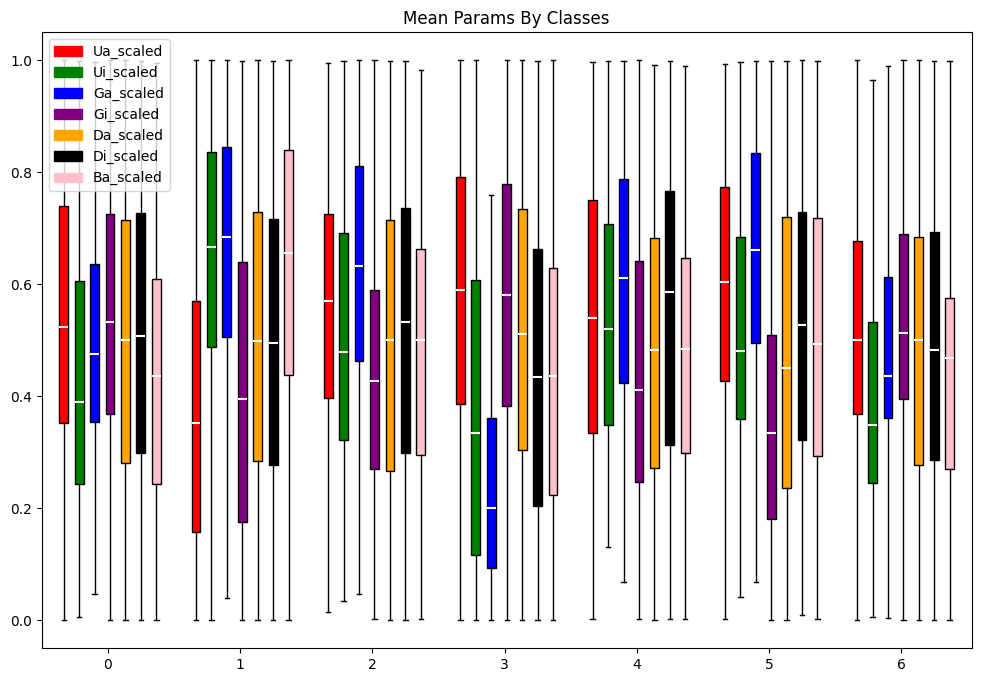

In [231]:
# print box plots for all 7 main params based on class 
feats = ['Ua_scaled', 'Ui_scaled', 'Ga_scaled', 'Gi_scaled', 'Da_scaled', 'Di_scaled', 'Ba_scaled']

classes = np.arange(0,num_classes)# list of unique clusters
fig, ax = plt.subplots(figsize = (12,8))

for i, class_df in enumerate(class_dfs):
  positions = np.arange(len(feats)) * 0.35 + i*3
  data = []

  for feat in feats:
     df = class_df[feat]
     data.append(df)

  # outliers not shown; to show outliers, set showfliers=True     
  bp = ax.boxplot(data, widths=0.2, positions=positions, patch_artist=True, showfliers=False,
              medianprops={'linewidth': 1.5, 'color':'white'})
  
  for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

ax.set(title = "Mean Params By Classes")

leg = ax.legend(['Ua_scaled', 'Ui_scaled', 'Ga_scaled', 'Gi_scaled', 'Da_scaled', 'Di_scaled', 'Ba_scaled'], loc="upper left")
leg = ax.get_legend()

for idx in range(len(colors)): 
    leg.legend_handles[idx].set_color(colors[idx])

ax.set_xticks([1,4,7,10,13,16,19])
ax.set_xticklabels(['0','1','2','3','4','5','6'])

# option_print = True
if option_print:
  plt.savefig(specific_file_dir + "Mean_All_Params_Scaled_By_Class.png", dpi = 300)
plt.show()

In [232]:
from sklearn.linear_model import LinearRegression

feat_1 = np.array(feats_df["num_spots"]).reshape(-1,1)
param_1 = np.array(feats_df["Ua"]).reshape(-1,1)

lin_reg=LinearRegression()
lin_reg.fit(feat_1,param_1)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [233]:
model = LinearRegression()

 #define predictor and response variables
feat_1 = np.array(feats_df["num_spots"]).reshape(-1,1)
param_1 = np.array(feats_df["Ua"]).reshape(-1,1)

# fit linear regression model
model.fit(param_1, feat_1)

#calculate R-squared (value indicating how well the data fits the regression model)
r_squared = model.score(param_1, feat_1)
print(r_squared)

0.026685643102544843


In [234]:
# calculate R-squared value for all features vs all params
all_params = ["Ua","Ui","Ga","Gi","Da","Di","Ba",'Ua/Ui', 'Ua/Ga', 'Ua/Gi', 'Ua/Da', 'Ua/Di', 'Ua/Ba', 'Ga/Gi', 'Ga/Da',
       'Ga/Di', 'Ga/Ba', 'Gi/Da', 'Gi/Di', 'Gi/Ba', 'Da/Di', 'Da/Ba', 'Di/Ba',
       'Ui/Gi', 'Ui/Da', 'Ui/Di', 'Ui/Ba']
feats = list(feats_df.columns[13:111])

p_list = []
f_list = []
r2 = []

for param in all_params:
  for feat in feats:
    model = LinearRegression()

    feat_1 = np.array(feats_df[feat]).reshape(-1,1)
    param_1 = np.array(feats_df[param]).reshape(-1,1)

    model.fit(param_1, feat_1)

    r_squared = model.score(param_1, feat_1)

    r2.append(r_squared)
    p_list.append(param)
    f_list.append(feat)

r2_dic = {"feat": f_list,"param":p_list,"r2":r2}
r2_df = pd.DataFrame(r2_dic)
r2_df.head()

,feat,param,r2
0,num_spots,Ua,0.026686
1,Mean,Ua,0.094981
2,Median,Ua,0.080573
3,Area_mean,Ua,0.008368
4,Area_std,Ua,0.000009


In [235]:
# prints highest to lowest R-squared values for given feature
r2_sorted = r2_df.sort_values(by=['r2'], ascending = False)

r2_sorted[r2_sorted["feat"] == "Mean"]

,feat,param,r2
1569,Mean,Ga/Ba,0.312211
197,Mean,Ga,0.282301
785,Mean,Ua/Ga,0.277238
1373,Mean,Ga/Da,0.262831
2549,Mean,Ui/Ba,0.257136
1275,Mean,Ga/Gi,0.240016
2255,Mean,Ui/Gi,0.198591
99,Mean,Ui,0.197997
2353,Mean,Ui/Da,0.187867
687,Mean,Ua/Ui,0.153818


In [ ]:
# plot the model predicted class in feature space
folder_name = "Param_By_Class_in_Feature_Space/"
os.makedirs(specific_file_dir + folder_name, exist_ok=True)

# features from num_spots to solidity_std
image_features = list(feats_df.columns[13:62])

classes = np.arange(0,num_classes)

for feat in image_features:
  for param in params:
    feat_1 = feat
    feat_2 = param

    fig, ax = plt.subplots()

    alpha = [1,1,1,1,1,1,0]
    for j in classes:
      df = class_dfs[j]
      ax.scatter(df[feat_1], df[feat_2], c = colors[j], label = "class " + str(j), alpha = alpha[j])

    leg = ax.legend(loc="upper left")
    ax.set(xlabel = feat_1, ylabel = feat_2)

    # option_print = True
    if "/" in feat_2:
      feat_2 = feat_2.replace("/","-")
    if option_print:
      plt.savefig(specific_file_dir + folder_name + feat_1 + "_vs_" + feat_2 + ".png", dpi = 300)
    plt.show()

In [248]:
# file that contains dataframe of features for each param value when other param values don't change; doesn't contain cluster info
with open("data/single_param_scans.pkl", 'rb') as f:
  single_dic = pickle.load(f) # deserialize using load()

In [249]:
single_dic["Ui"].head(20)

,Ua,Ui,Ga,Gi,Ba,Da,Di,pattern,noise,path,seed,dir,feat_bool,num_spots,Mean,Median,Area_mean,Area_std,X_mean,X_std,Y_mean,Y_std,Perim._mean,Perim._std,BX_mean,BX_std,BY_mean,BY_std,Width_mean,Width_std,Height_mean,Height_std,Major_mean,Major_std,Minor_mean,Minor_std,Angle_mean,Angle_std,Circ._mean,Circ._std,Feret_mean,Feret_std,IntDen_mean,IntDen_std,%Area_mean,%Area_std,RawIntDen_mean,RawIntDen_std,FeretX_mean,FeretX_std,FeretY_mean,FeretY_std,FeretAngle_mean,FeretAngle_std,MinFeret_mean,MinFeret_std,AR_mean,AR_std,Round_mean,Round_std,Solidity_mean,Solidity_std,num_spots_inverted,Mean_inverted,Median_inverted,Area_inverted_mean,Area_inverted_std,X_inverted_mean,X_inverted_std,Y_inverted_mean,Y_inverted_std,Perim._inverted_mean,Perim._inverted_std,BX_inverted_mean,BX_inverted_std,BY_inverted_mean,BY_inverted_std,Width_inverted_mean,Width_inverted_std,Height_inverted_mean,Height_inverted_std,Major_inverted_mean,Major_inverted_std,Minor_inverted_mean,Minor_inverted_std,Angle_inverted_mean,Angle_inverted_std,Circ._inverted_mean,Circ._inverted_std,Feret_inverted_mean,Feret_inverted_std,IntDen_inverted_mean,IntDen_inverted_std,%Area_inverted_mean,%Area_inverted_std,RawIntDen_inverted_mean,RawIntDen_inverted_std,FeretX_inverted_mean,FeretX_inverted_std,FeretY_inverted_mean,FeretY_inverted_std,FeretAngle_inverted_mean,FeretAngle_inverted_std,MinFeret_inverted_mean,MinFeret_inverted_std,AR_inverted_mean,AR_inverted_std,Round_inverted_mean,Round_inverted_std,Solidity_inverted_mean,Solidity_inverted_std
0,0.03,0.03585858585858586,0.08,0.1,-0.12,0.01,0.5,0,2,14936.png,14936,/content/05-09-2024_all_images/,1,0,0.000,0,40000.000000,0.000000,100.000000,0.000000,100.000000,0.000000,800.000000,0.000000,0.000000,0.000000,0.000000,0.000000,200.000000,0.000000,200.000000,0.000000,225.676000,0.000000,225.676000,0.000000,0.000000,0.000000,0.785000,0.000000,282.843000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,135.000000,0.000000,200.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1,255.000,255,40000.0,0.0,100.000,0.0,100.000,0.0,797.657,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,225.676,0.0,225.676,0.0,0.000,0.0,0.790,0.0,282.843,0.0,10200000.0,0.0,100.0,0.0,10200000.0,0.0,0.0,0.0,0.0,0.0,135.0,0.0,200.0,0.0,1.0,0.0,1.0,0.0,1.000,0.0
1,0.03,0.03671717171717172,0.08,0.1,-0.12,0.01,0.5,0,2,14937.png,14937,/content/05-09-2024_all_images/,1,0,0.000,0,40000.000000,0.000000,100.000000,0.000000,100.000000,0.000000,800.000000,0.000000,0.000000,0.000000,0.000000,0.000000,200.000000,0.000000,200.000000,0.000000,225.676000,0.000000,225.676000,0.000000,0.000000,0.000000,0.785000,0.000000,282.843000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,135.000000,0.000000,200.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1,255.000,255,40000.0,0.0,100.000,0.0,100.000,0.0,797.657,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,225.676,0.0,225.676,0.0,0.000,0.0,0.790,0.0,282.843,0.0,10200000.0,0.0,100.0,0.0,10200000.0,0.0,0.0,0.0,0.0,0.0,135.0,0.0,200.0,0.0,1.0,0.0,1.0,0.0,1.000,0.0
2,0.03,0.03757575757575758,0.08,0.1,-0.12,0.01,0.5,0,2,14938.png,14938,/content/05-09-2024_all_images/,1,0,0.000,0,40000.000000,0.000000,100.000000,0.000000,100.000000,0.000000,800.000000,0.000000,0.000000,0.000000,0.000000,0.000000,200.000000,0.000000,200.000000,0.000000,225.676000,0.000000,225.676000,0.000000,0.000000,0.000000,0.785000,0.000000,282.843000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,135.000000,0.000000,200.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1,255.000,255,40000.0,0.0,100.000,0.0,100.000,0.0,797.657,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,225.676,0.0,225.676,0.0,0.000,0.0,0.790,0.0,282.843,0.0,10200000.0,0.0,100.0,0.0,10200000.0,0.0,0.0,0.0,0.0,0.0,135.0,0.0,200.0,0.0,1.0,0.0,1.0,0.0,1.000,0.0
3,0.03,0.03843434343434344,0.08,0.1,-0.12,0.01,0.5,0,2,14939.png,14939,/content/05-0

In [250]:
# create a new dictionary containing the cluster info by searching for the paths in feats_df_large
# note: this is not on the narrow param domain like before
indices = {"Ua":[],"Ui":[],"Ga":[],"Gi":[],"Da":[],"Di":[],"Ba":[]}

for i in single_dic.keys():
    df = single_dic[i]
    df.reset_index(inplace=True, drop=True)
    for j in range(df.shape[0]):
        path = df["path"][j]
        line = feats_df_large[feats_df_large["path"] == path]
        indices[i].append(line.index[0])

single_classes = {"Ua":None,"Ui":None,"Ga":None,"Gi":None,"Da":None,"Di":None,"Ba":None}

for i in indices.keys():
  ind_list = indices[i]
  df = feats_df_large.iloc[ind_list]
  df.reset_index(inplace = True, drop = True)
  single_classes[i] = df

In [251]:
# now shows dataframe with cluster info
single_classes["Ua"].head()

,Ua,Ui,Ga,Gi,Ba,Da,Di,pattern,noise,path,seed,dir,feat_bool,num_spots,Mean,Median,Area_mean,Area_std,X_mean,X_std,Y_mean,Y_std,Perim._mean,Perim._std,BX_mean,BX_std,BY_mean,BY_std,Width_mean,Width_std,Height_mean,Height_std,Major_mean,Major_std,Minor_mean,Minor_std,Angle_mean,Angle_std,Circ._mean,Circ._std,Feret_mean,Feret_std,IntDen_mean,IntDen_std,%Area_mean,%Area_std,RawIntDen_mean,RawIntDen_std,FeretX_mean,FeretX_std,FeretY_mean,FeretY_std,FeretAngle_mean,FeretAngle_std,MinFeret_mean,MinFeret_std,AR_mean,AR_std,Round_mean,Round_std,Solidity_mean,Solidity_std,num_spots_inverted,Mean_inverted,Median_inverted,Area_inverted_mean,Area_inverted_std,X_inverted_mean,X_inverted_std,Y_inverted_mean,Y_inverted_std,Perim._inverted_mean,Perim._inverted_std,BX_inverted_mean,BX_inverted_std,BY_inverted_mean,BY_inverted_std,Width_inverted_mean,Width_inverted_std,Height_inverted_mean,Height_inverted_std,Major_inverted_mean,Major_inverted_std,Minor_inverted_mean,Minor_inverted_std,Angle_inverted_mean,Angle_inverted_std,Circ._inverted_mean,Circ._inverted_std,Feret_inverted_mean,Feret_inverted_std,IntDen_inverted_mean,IntDen_inverted_std,%Area_inverted_mean,%Area_inverted_std,RawIntDen_inverted_mean,RawIntDen_inverted_std,FeretX_inverted_mean,FeretX_inverted_std,FeretY_inverted_mean,FeretY_inverted_std,FeretAngle_inverted_mean,FeretAngle_inverted_std,MinFeret_inverted_mean,MinFeret_inverted_std,AR_inverted_mean,AR_inverted_std,Round_inverted_mean,Round_inverted_std,Solidity_inverted_mean,Solidity_inverted_std,pc1,pc2,cluster
0,0.0067,0.07,0.08,0.1,-0.12,0.01,0.5,0,2,14735.png,14735,/content/Images3/,1,1,255.0,255,40000.0,0.0,100.0,0.0,100.0,0.0,797.657,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,225.676,0.0,225.676,0.0,0.0,0.0,0.79,0.0,282.843,0.0,10200000.0,0.0,100.0,0.0,10200000.0,0.0,0.0,0.0,0.0,0.0,135.0,0.0,200.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0,0.0,0,40000.0,0.0,100.0,0.0,100.0,0.0,800.0,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,225.676,0.0,225.676,0.0,0.0,0.0,0.785,0.0,282.843,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,135.0,0.0,200.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,-4.316102,-2.970861,1
1,0.006834343434343434,0.07,0.08,0.1,-0.12,0.01,0.5,0,2,14736.png,14736,/content/Images3/,1,1,255.0,255,40000.0,0.0,100.0,0.0,100.0,0.0,797.657,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,225.676,0.0,225.676,0.0,0.0,0.0,0.79,0.0,282.843,0.0,10200000.0,0.0,100.0,0.0,10200000.0,0.0,0.0,0.0,0.0,0.0,135.0,0.0,200.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0,0.0,0,40000.0,0.0,100.0,0.0,100.0,0.0,800.0,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,225.676,0.0,225.676,0.0,0.0,0.0,0.785,0.0,282.843,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,135.0,0.0,200.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,-4.316102,-2.970861,1
2,0.006968686868686869,0.07,0.08,0.1,-0.12,0.01,0.5,0,2,14737.png,14737,/content/Images3/,1,1,255.0,255,40000.0,0.0,100.0,0.0,100.0,0.0,797.657,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,225.676,0.0,225.676,0.0,0.0,0.0,0.79,0.0,282.843,0.0,10200000.0,0.0,100.0,0.0,10200000.0,0.0,0.0,0.0,0.0,0.0,135.0,0.0,200.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0,0.0,0,40000.0,0.0,100.0,0.0,100.0,0.0,800.0,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,225.676,0.0,225.676,0.0,0.0,0.0,0.785,0.0,282.843,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,135.0,0.0,200.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,-4.316102,-2.970861,1
3,0.007103030303030303,0.07,0.08,0.1,-0.12,0.01,0.5,0,2,14738.png,14738,/content/Images3/,1,1,255.0,255,40000.0,0.0,100.0,0.0,100.0,0.0,797.657,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,225.676,0.0,225.676,0.0,0.0,0.0,0.79,0.0,282.843,0.0,10200000.0,0.0,100.0,0.0,10200000.0,0.0,0.0,0.0,0.0,0.0,135.0,0.0,200.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0,0.0,0,40000.0,0.0,100.0,0.0,100.0,0.0,800.0,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,225.676,0.0,225.676,0.0,0.0,0.0,0.785,0.0,282.843,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,135.0,0.0,200.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,-4.316102,-2.970861,1
4,0.007237373737373738,0.07,0.08,0.1,-0.12,0.01,0.5,0,2,14739.png,14739,/content/Images3/,1,1,255.0,255,40000.0,0.0,100.0,0.0,100.0,0.0,797.657,0.0

Ua = 0.0067, Ui = 0.03585858585858586, Ga = 0.0552, Gi = 0.017, Da = 0.0, Di = 0.143, Ba = -0.030700000000000005, 

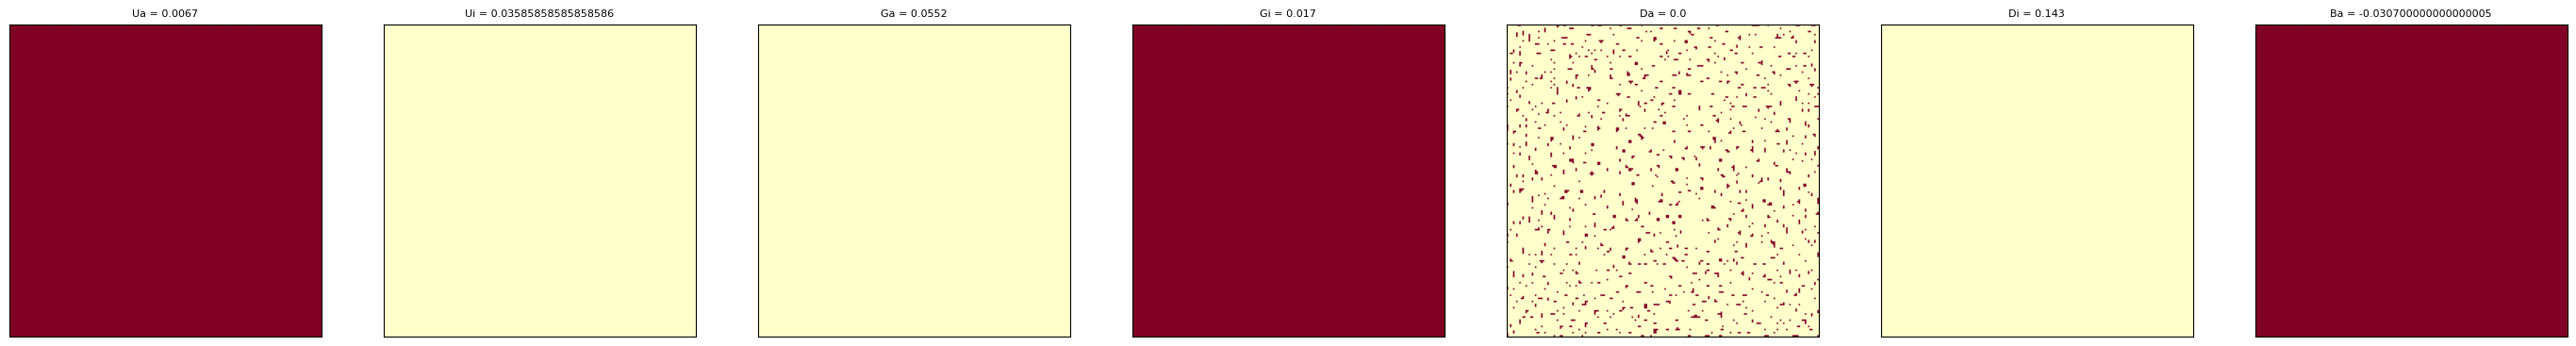

Ua = 0.006834343434343434, Ui = 0.03671717171717172, Ga = 0.055905050505050506, Gi = 0.01809090909090909, Da = 0.0012121212121212121, Di = 0.15155555555555555, Ba = -0.031854545454545455, 

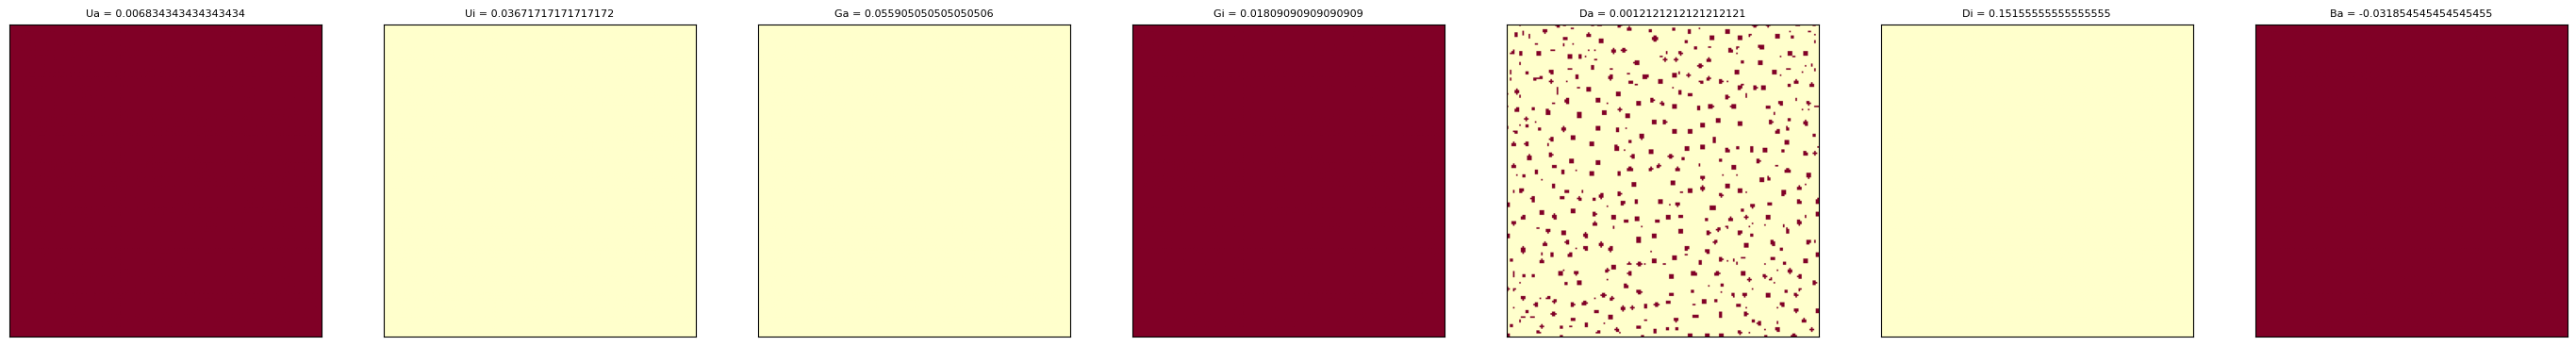

Ua = 0.006968686868686869, Ui = 0.03757575757575758, Ga = 0.056610101010101006, Gi = 0.019181818181818182, Da = 0.0015151515151515152, Di = 0.1601111111111111, Ba = -0.03300909090909092, 

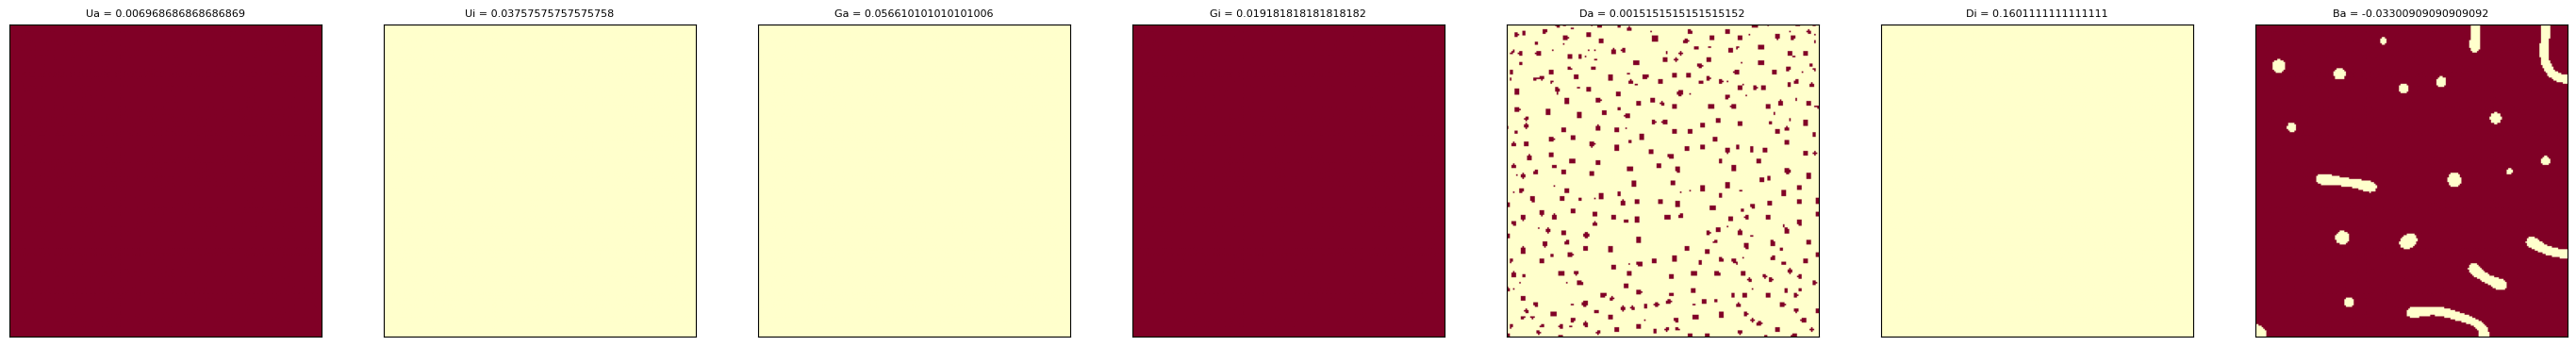

Ua = 0.007103030303030303, Ui = 0.03843434343434344, Ga = 0.05731515151515151, Gi = 0.020272727272727276, Da = 0.0018181818181818182, Di = 0.16866666666666666, Ba = -0.03416363636363637, 

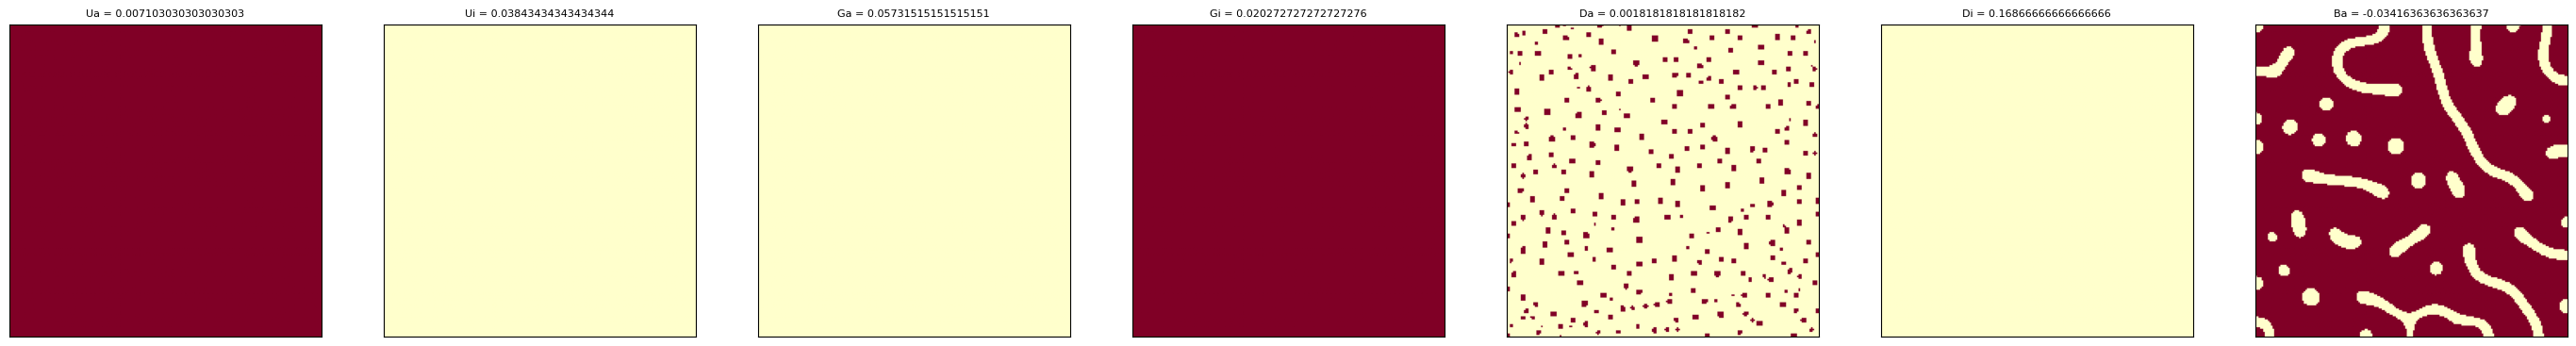

Ua = 0.007237373737373738, Ui = 0.039292929292929296, Ga = 0.05802020202020202, Gi = 0.021363636363636366, Da = 0.002121212121212121, Di = 0.17722222222222223, Ba = -0.03531818181818183, 

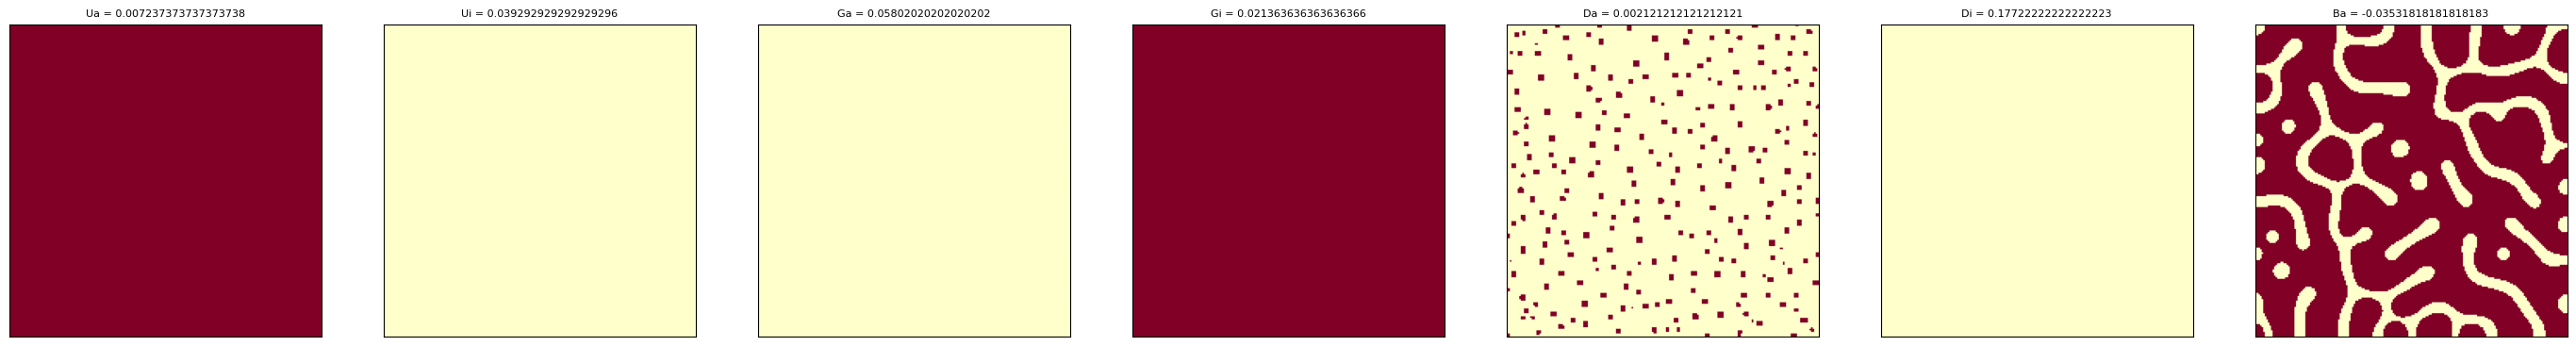

Ua = 0.007371717171717172, Ui = 0.04015151515151515, Ga = 0.05872525252525253, Gi = 0.022454545454545456, Da = 0.0024242424242424242, Di = 0.18577777777777776, Ba = -0.03647272727272728, 

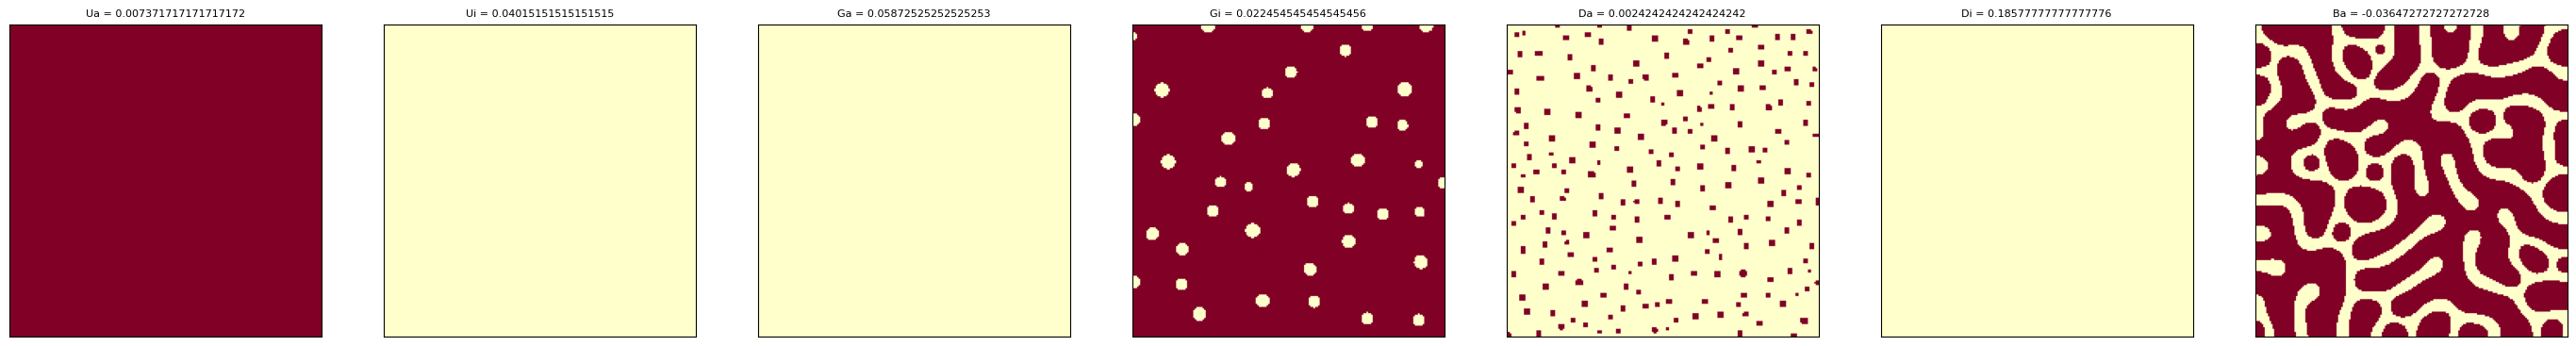

Ua = 0.007506060606060606, Ui = 0.04101010101010101, Ga = 0.05943030303030303, Gi = 0.023545454545454546, Da = 0.002727272727272727, Di = 0.19433333333333333, Ba = -0.03762727272727273, 

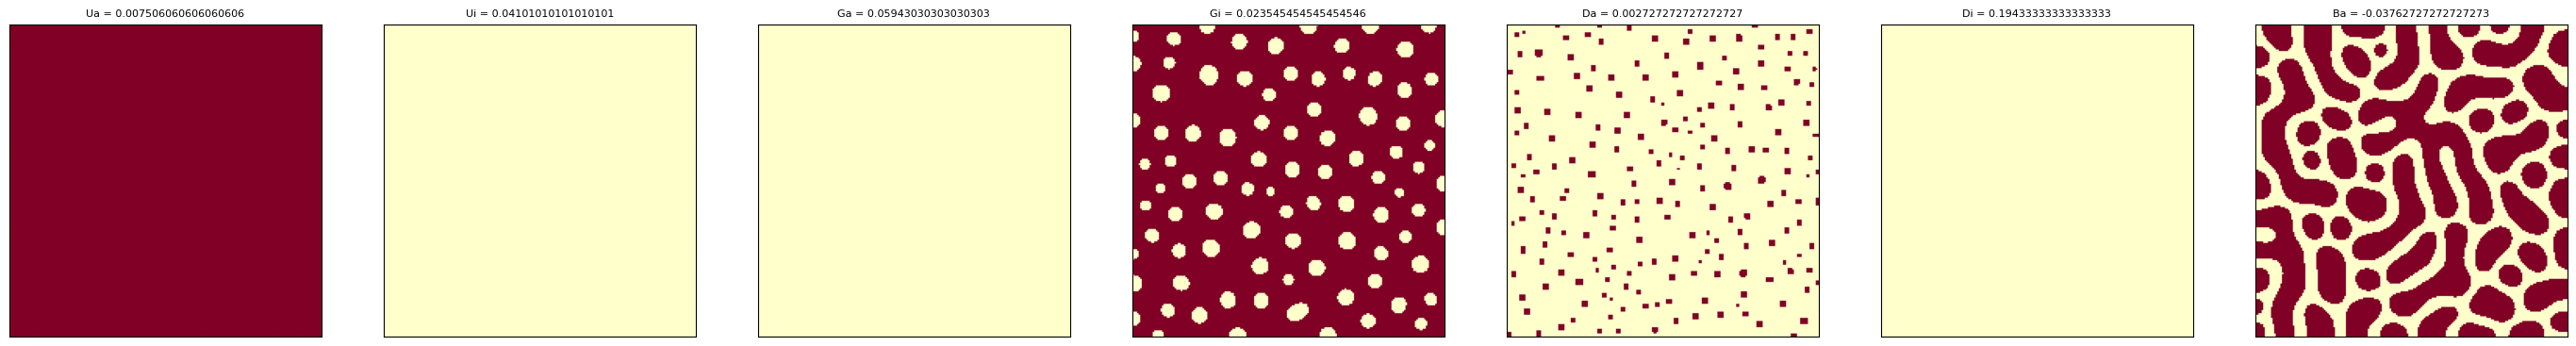

Ua = 0.00764040404040404, Ui = 0.041868686868686875, Ga = 0.060135353535353535, Gi = 0.024636363636363637, Da = 0.0030303030303030303, Di = 0.20288888888888887, Ba = -0.03878181818181818, 

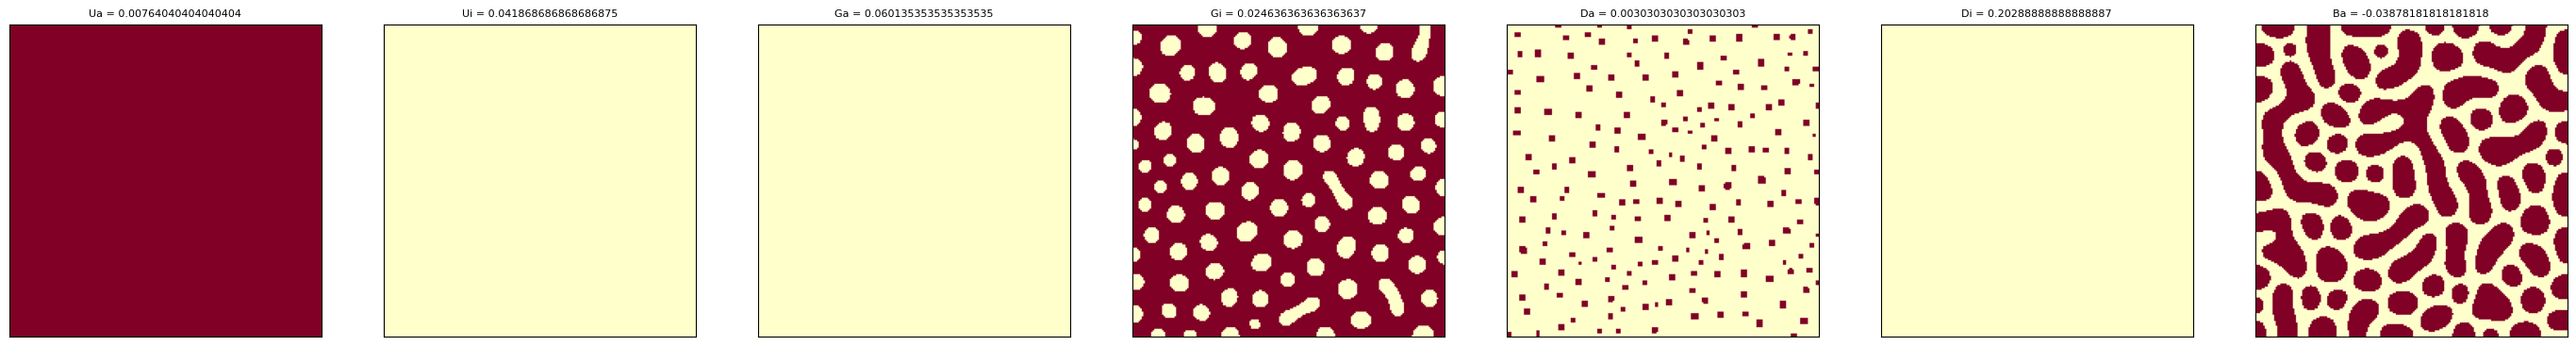

Ua = 0.007774747474747475, Ui = 0.04272727272727273, Ga = 0.06084040404040404, Gi = 0.02572727272727273, Da = 0.003333333333333333, Di = 0.21144444444444443, Ba = -0.03993636363636363, 

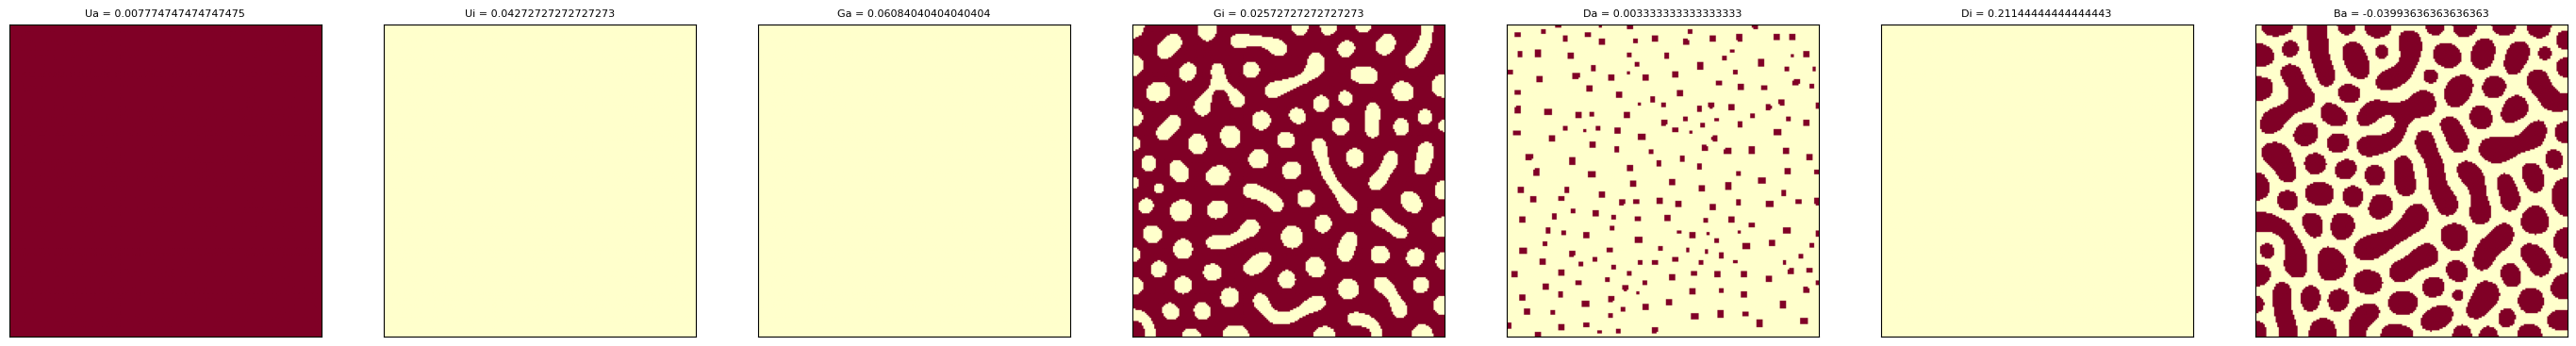

Ua = 0.007909090909090909, Ui = 0.04358585858585859, Ga = 0.06154545454545454, Gi = 0.026818181818181817, Da = 0.0036363636363636364, Di = 0.21999999999999997, Ba = -0.041090909090909095, 

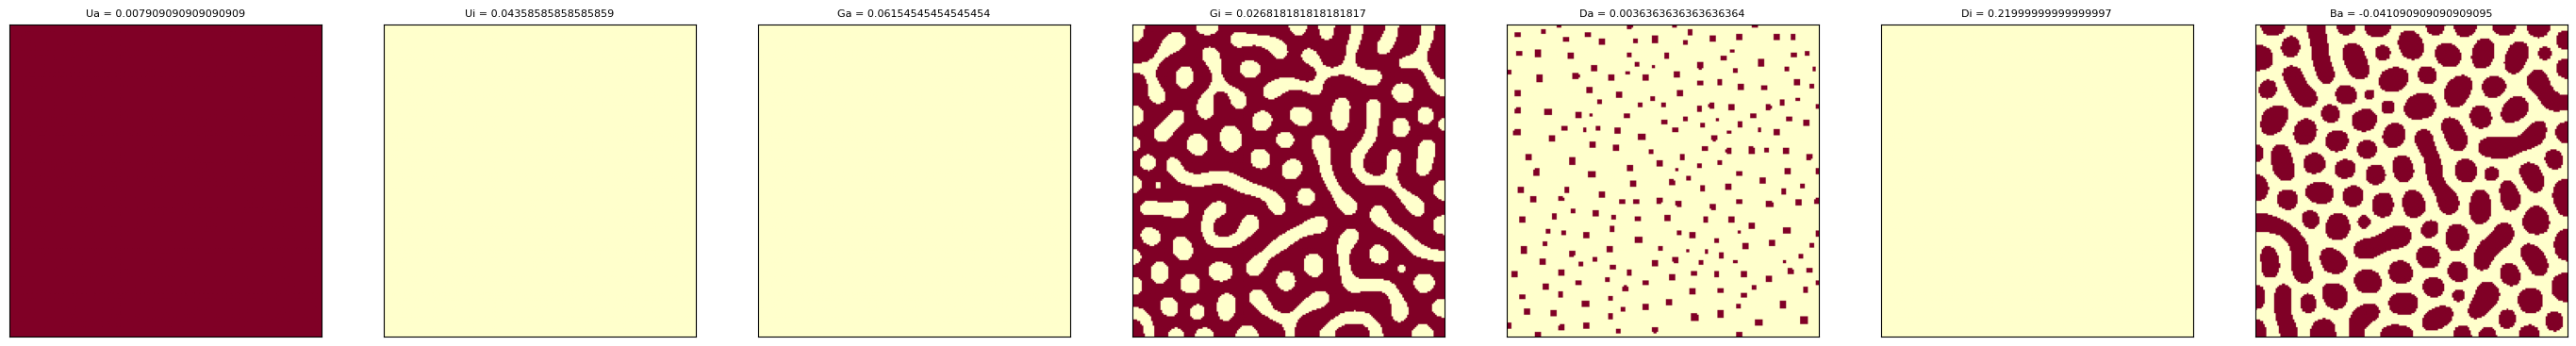

In [256]:
#sort all the dfs
for i in single_classes.keys():
  df = single_classes[i].copy()
  df[params] = df[params].astype(float)
  df = df.sort_values(by = i)
  single_classes[i] = df

# print out random images from clusters
num_imgs = 10

for i in range(num_imgs):
  fig, ax = plt.subplots(1,len(params))
  for j in range(len(params)):
    df = single_classes[params[j]]
    path = df["dir"][i] + df["path"][i]
    img = np.array(Image.open(path[1:]))
    ax[j].imshow(img, cmap = "YlOrRd", vmin = 0, vmax = 255)
    ax[j].set_title(str(params[j]) + " = "+ str(df[params[j]][i]), fontsize = 8)
    print(str(params[j]) + " = "+ str(df[params[j]][i]), end=", ")
    ax[j].get_xaxis().set_visible(False)
    ax[j].get_yaxis().set_visible(False)
   
  fig.set_figwidth(5*len(params))
  fig.set_figheight(5*num_imgs)

  # option_print = True
  # if option_print:
  #   plt.savefig(specific_file_dir + "Single_Param_Scans_Random_Images_By_Class" + str(i) + ".png", dpi = 300)
  plt.show()


In [ ]:
# plot some dependencies
folder_name = "Linear_Scans_Feat_vs_Param/"
os.makedirs(specific_file_dir + folder_name, exist_ok=True)

keys = list(single_classes.keys())
feat = "num_spots"

# iterate through params
for feat in image_features:
  for i in range(len(keys)):
    fig, ax = plt.subplots()
    # iterate through classes
    for j in range(num_classes):
      # pull up the dataframe for the specific class
      df = single_classes[keys[i]]
      df = df[df["cluster"] == j]
      df.reset_index(inplace = True, drop = True)

      x = df[keys[i]].astype(float)
      y = df[feat].astype(float)

      ax.scatter(x,y, color = colors[j])
    ax.legend([0,1,2,3,4,5,6])
    ax.set(title = f"Dependency of {feat} on {keys[i]}", xlabel = keys[i], ylabel = feat)

    # option_print = True
    if option_print:
      plt.savefig(specific_file_dir + folder_name + feat + "_vs_" + keys[i] + "_SingleParamScan.png", dpi = 300)
    plt.show()